In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('imdb_top_1000.csv')
df

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,https://m.media-amazon.com/images/M/MV5BNGEwMT...,Breakfast at Tiffany's,1961,A,115 min,"Comedy, Drama, Romance",7.6,A young New York socialite becomes interested ...,76.0,Blake Edwards,Audrey Hepburn,George Peppard,Patricia Neal,Buddy Ebsen,166544,NaN
996,https://m.media-amazon.com/images/M/MV5BODk3Yj...,Giant,1956,G,201 min,"Drama, Western",7.6,Sprawling epic covering the life of a Texas ca...,84.0,George Stevens,Elizabeth Taylor,Rock Hudson,James Dean,Carroll Baker,34075,NaN
997,https://m.media-amazon.com/images/M/MV5BM2U3Yz...,From Here to Eternity,1953,Passed,118 min,"Drama, Romance, War",7.6,"In Hawaii in 1941, a private is cruelly punish...",85.0,Fred Zinnemann,Burt Lancaster,Montgomery Clift,Deborah Kerr,Donna Reed,43374,"30,500,000"
998,https://m.media-amazon.com/images/M/MV5BZTBmMj...,Lifeboat,1944,NaN,97 min,"Drama, War",7.6,Several survivors of a torpedoed merchant ship...,78.0,Alfred Hitchcock,Tallulah Bankhead,John Hodiak,Walter Slezak,William Bendix,26471,NaN


# **`Descriptive Analysis`:**

# **Movie Industry Trends**

Total movies per year

In [3]:
df = df.groupby('Released_Year')['Series_Title'].count()

In [4]:
df


,Series_Title
Released_Year,
1920,1
1921,1
1922,1
1924,1
1925,2
...,...
2017,22
2018,19
2019,23


Average IMDb rating per year

In [5]:
import pandas as pd
df = pd.read_csv('imdb_top_1000.csv')
df = df.groupby('Released_Year')['IMDB_Rating'].mean()
df

,IMDB_Rating
Released_Year,
1920,8.100000
1921,8.300000
1922,7.900000
1924,8.200000
1925,8.100000
...,...
2017,7.890909
2018,7.994737
2019,7.995652


Most popular genre over time

In [6]:
import pandas as pd
df = pd.read_csv('imdb_top_1000.csv')
df['Genre'] = df['Genre'].str.split(',')
df = df.explode('Genre')

In [7]:
genre_trend = df.groupby(['Released_Year','Genre']).size().reset_index(name='Count')

Plot Trends

In [8]:
top_genre = df['Genre'].value_counts().head(5).index
filtered = genre_trend[genre_trend['Genre'].isin(top_genre)]

In [9]:
pivot_table = filtered.pivot_table(index='Released_Year',columns='Genre',values='Count').fillna(0)

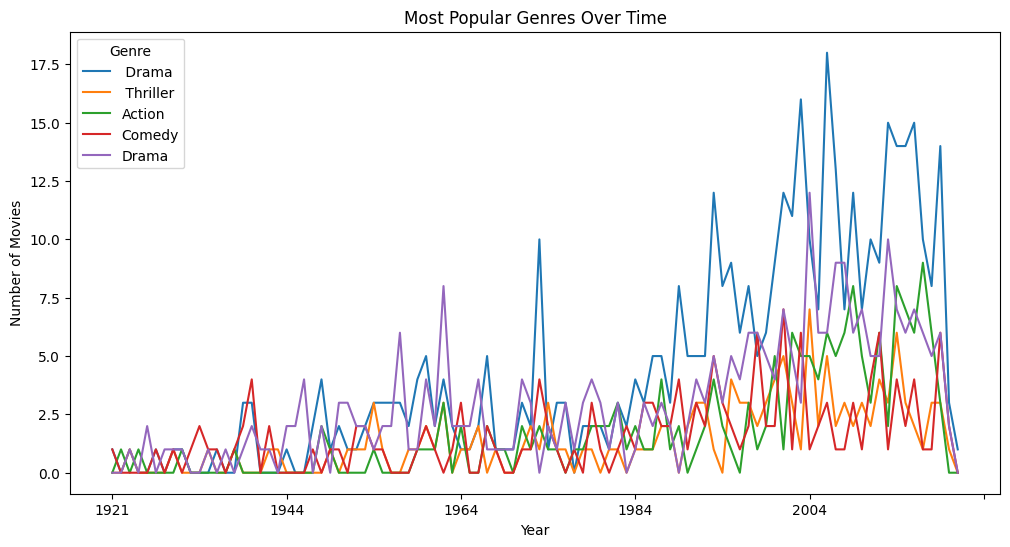

In [10]:
import matplotlib.pyplot as plt
pivot_table.plot(figsize=(12,6))
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.title('Most Popular Genres Over Time')
plt.show()

Insights

->Drama stays consistently dominant

->Action grows in recent years

# **Revenue Analysis**

Top 10 highest grossing movies

In [11]:
import pandas as pd
df = pd.read_csv('imdb_top_1000.csv')
df['Gross'] = df['Gross'].str.replace(',','')
df['Gross'] = pd.to_numeric(df['Gross'],errors='coerce')
df = df.dropna(subset='Gross')
Highest_Gross = df[['Series_Title','Gross']].sort_values(by='Gross',ascending=False).head(10)
Highest_Gross

,Series_Title,Gross
477,Star Wars: Episode VII - The Force Awakens,936662225.0
59,Avengers: Endgame,858373000.0
623,Avatar,760507625.0
60,Avengers: Infinity War,678815482.0
652,Titanic,659325379.0
357,The Avengers,623279547.0
891,Incredibles 2,608581744.0
2,The Dark Knight,534858444.0
582,Rogue One,532177324.0
63,The Dark Knight Rises,448139099.0


Revenue by genre

In [12]:
df['Gross'] = df['Gross'].fillna(0)
df['Genre'] = df['Genre'].str.split(',')
df = df.explode('Genre')

genre_revenue = df.groupby('Genre')['Gross'].mean().sort_values(ascending=False)
genre_revenue

,Gross
Genre,
Family,2.195553e+08
Adventure,2.100969e+08
Sci-Fi,1.480264e+08
Action,1.419631e+08
Action,1.344355e+08
Comedy,1.283035e+08
Animation,1.279675e+08
Fantasy,1.086168e+08
Family,8.742733e+07


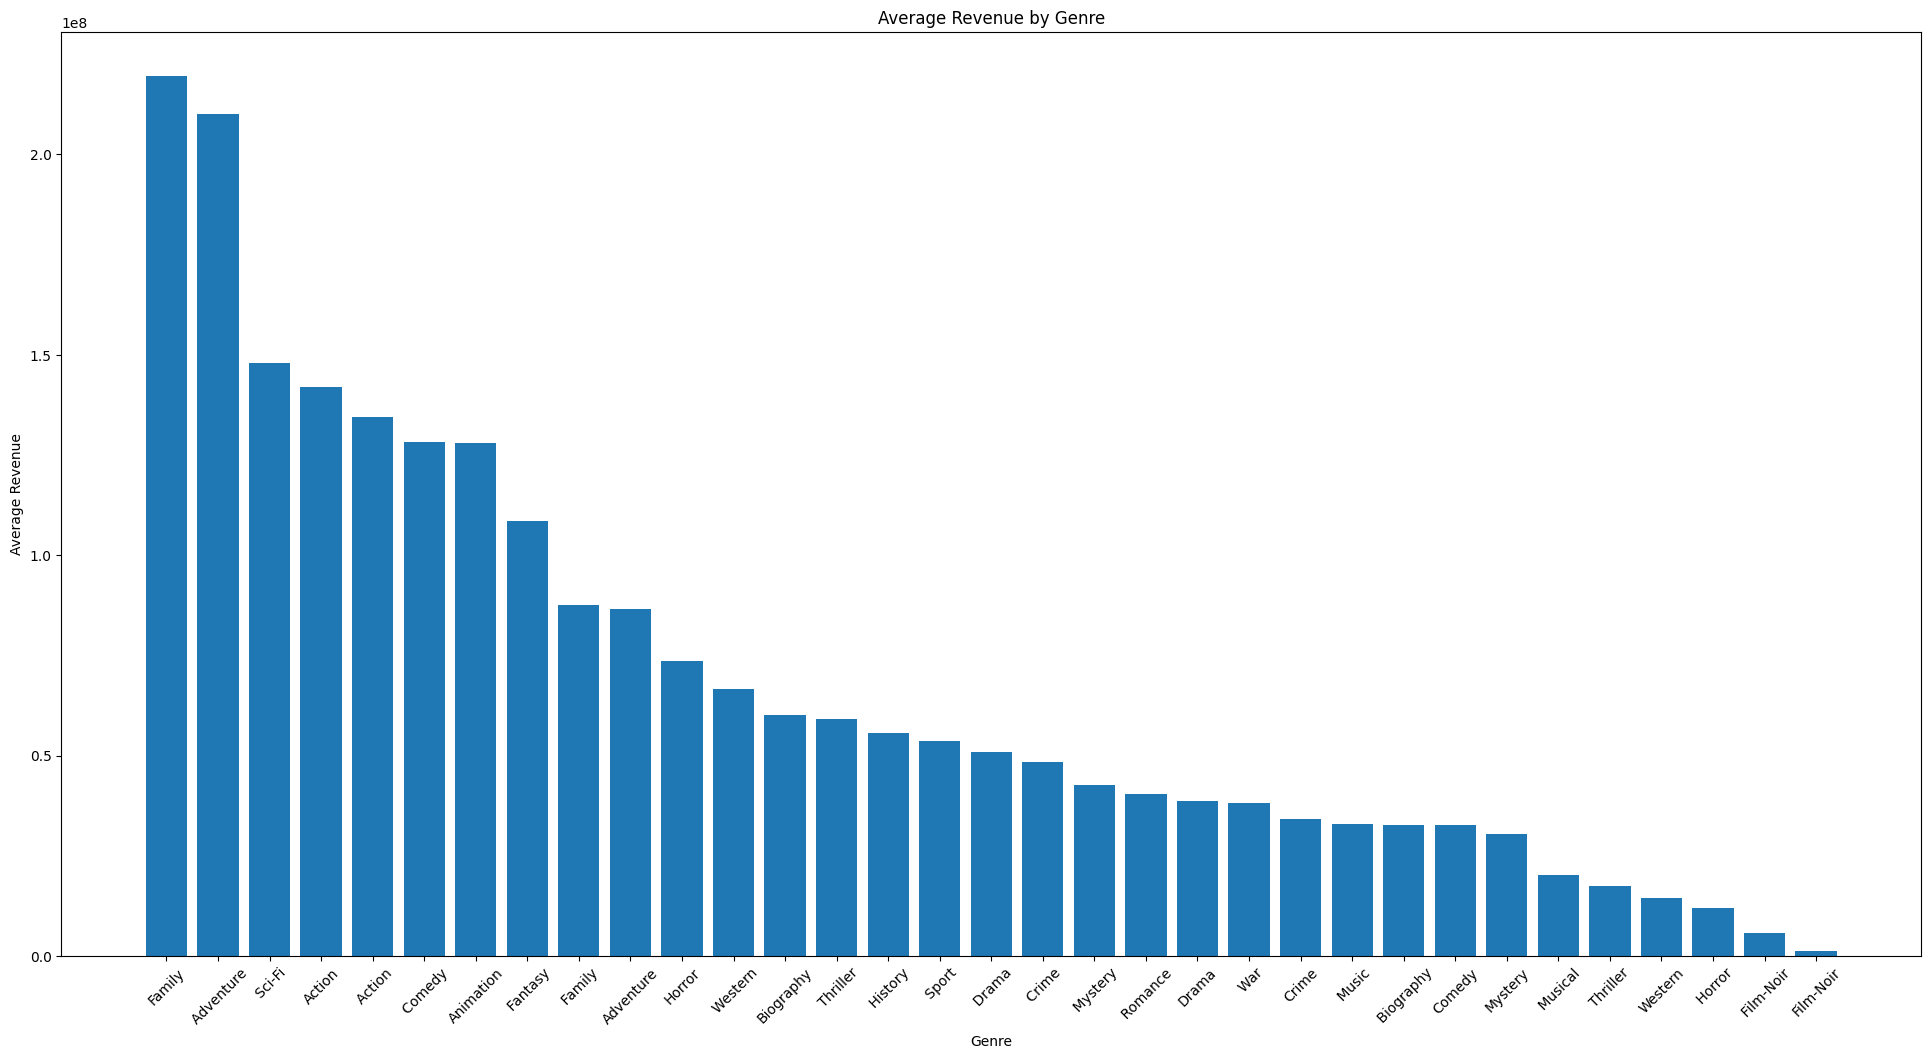

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(24,12))
plt.bar(genre_revenue.index,genre_revenue.values)
plt.xlabel('Genre')
plt.ylabel('Average Revenue')
plt.title('Average Revenue by Genre')
plt.xticks(rotation=45)
plt.show()

Revenue vs IMDb rating

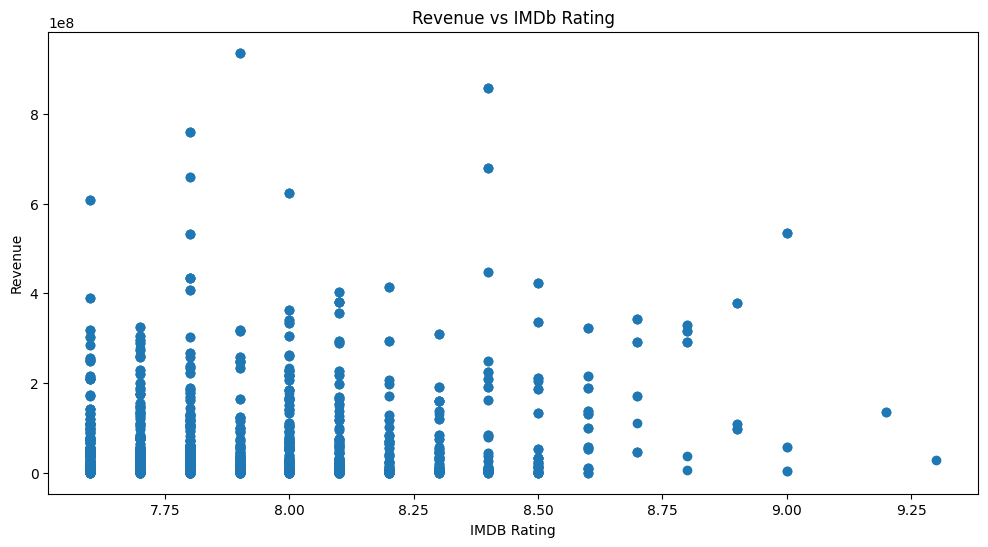

In [14]:
plt.figure(figsize=(12,6))
plt.scatter(df['IMDB_Rating'],df['Gross'])
plt.xlabel('IMDB Rating')
plt.ylabel('Revenue')
plt.title('Revenue vs IMDb Rating')
plt.show()

Insights

-> Family and Adventure genres are most grossed genres

->Star Wars: Episode VII - The Force Awakens is the most grossed movie with a revenue of $936662225.0

# **Rating & Popularity**

Distribution of IMDb rating

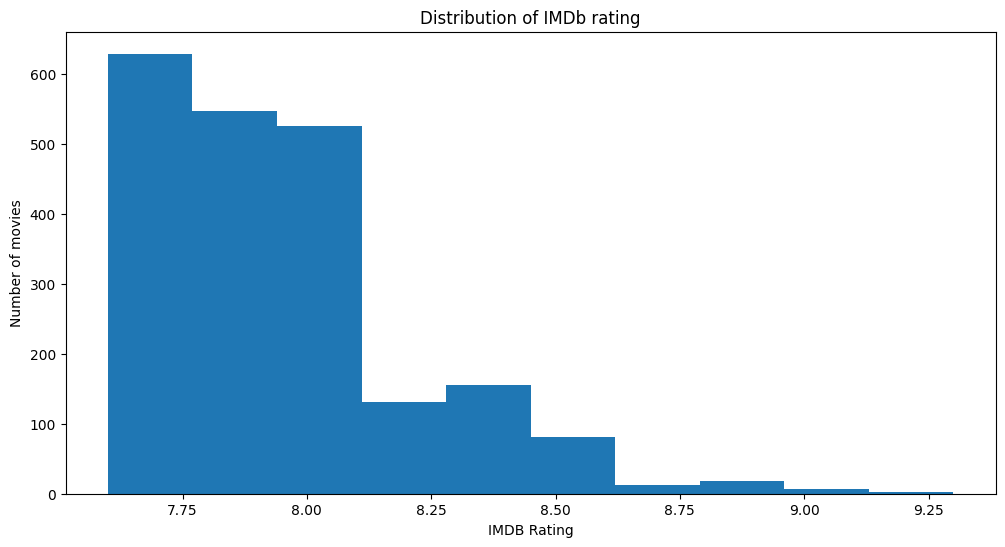

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.hist(df['IMDB_Rating'])
plt.title('Distribution of IMDb rating')
plt.xlabel('IMDB Rating')
plt.ylabel('Number of movies')
plt.show()

Insights

-> Most movies are concentrated between ratings 7 and 8

Top Director based on average rating

In [16]:
director_rating = df.groupby('Director')['IMDB_Rating'].mean()
Top_Director = director_rating.sort_values(ascending=False)
Top_Director

,IMDB_Rating
Director,
Frank Darabont,8.775
Lana Wachowski,8.700
Irvin Kershner,8.700
George Lucas,8.600
Fernando Meirelles,8.600
...,...
Ted Demme,7.600
Brian G. Hutton,7.600
Bradley Cooper,7.600


Insights

->Top Director based on average rating is Frank Darabont with 8.775 rating out of 10

Top Actors based on movie success

In [17]:

actor_revenue = df.groupby('Star1')['Gross'].mean()
top_actor_revenue = actor_revenue.sort_values(ascending=False)
top_actor_revenue

,Gross
Star1,
Daisy Ridley,9.366622e+08
Sam Worthington,7.605076e+08
Joe Russo,5.512599e+08
Felicity Jones,5.321773e+08
Henry Thomas,4.351106e+08
...,...
Abhay Deol,1.095000e+04
Rajat Barmecha,7.461000e+03
Won Bin,6.460000e+03


# **Genre Analysis**

Most frequent genres

In [18]:
df['Genre'] = df['Genre'].str.split(',')
df = df.explode('Genre')
genre_counts = df['Genre'].value_counts()
genre_counts

,count
Genre,
Drama,363
Drama,234
Action,141
Comedy,128
Adventure,109
Thriller,109
Romance,107
Crime,93
Biography,79


Average rating per genre

In [19]:
df = df.groupby('Genre')['IMDB_Rating'].mean()
Average_rating_per_genre = df.sort_values(ascending=False)
Average_rating_per_genre

,IMDB_Rating
Genre,
Western,8.350000
Mystery,8.066667
Film-Noir,8.050000
Crime,8.021505
War,8.018919
Film-Noir,8.000000
Sci-Fi,7.991803
Adventure,7.977982
Mystery,7.957333


Revenue per genre

In [20]:
import pandas as pd
df = pd.read_csv('imdb_top_1000.csv')
df['Gross'] = df['Gross'].str.replace(',','')
df['Gross'] = pd.to_numeric(df['Gross'],errors='coerce')
df = df.dropna(subset='Gross')
df['Genre'] = df['Genre'].str.split(',')
df = df.explode('Genre')
Revenue = df.groupby('Genre')['Gross'].mean()
Revenue_per_genre = Revenue.sort_values(ascending=False)
Revenue_per_genre

,Gross
Genre,
Family,2.195553e+08
Adventure,2.100969e+08
Sci-Fi,1.480264e+08
Action,1.419631e+08
Action,1.344355e+08
Comedy,1.283035e+08
Animation,1.279675e+08
Fantasy,1.086168e+08
Family,8.742733e+07


# **Director & Cast Impact**

Directors with most movies

In [21]:
import pandas as pd
df = pd.read_csv('imdb_top_1000.csv')
director_counts = df['Director'].value_counts()
director_counts

,count
Director,
Alfred Hitchcock,14
Steven Spielberg,13
Hayao Miyazaki,11
Akira Kurosawa,10
Martin Scorsese,10
...,...
Kinji Fukasaku,1
Eric Bress,1
Thomas Kail,1


Actors appearing in highest-rated films

In [22]:
df = df.groupby('Star1')['IMDB_Rating'].mean()
actor_popularity= df.sort_values(ascending=False)
actor_popularity

,IMDB_Rating
Star1,
Tim Robbins,9.30
John Travolta,8.90
Elijah Wood,8.80
Lilly Wachowski,8.70
Marlon Brando,8.65
...,...
Barry Cook,7.60
Ansel Elgort,7.60
Antonio Banderas,7.60


Correlation between cast popularity and revenue

In [23]:
import pandas as pd
df = pd.read_csv('imdb_top_1000.csv')
df['Gross'] = df['Gross'].str.replace(',','')
df['Gross'] = pd.to_numeric(df['Gross'],errors='coerce')
df = df.dropna(subset='Gross')
df['Genre'] = df['Genre'].str.split(',')
df = df.explode('Genre')
Revenue = df.groupby('Genre')['Gross'].mean()
Revenue_per_genre = Revenue.sort_values(ascending=False)
Revenue_per_genre

,Gross
Genre,
Family,2.195553e+08
Adventure,2.100969e+08
Sci-Fi,1.480264e+08
Action,1.419631e+08
Action,1.344355e+08
Comedy,1.283035e+08
Animation,1.279675e+08
Fantasy,1.086168e+08
Family,8.742733e+07


In [24]:
df['Cast_Popularity'] = (
    df['Star1'].map(actor_popularity) +
    df['Star2'].map(actor_popularity) +
    df['Star3'].map(actor_popularity) +
    df['Star4'].map(actor_popularity)
) / 4

Text(0.5, 1.0, 'Correlation between Cast Popularity and Revenue')

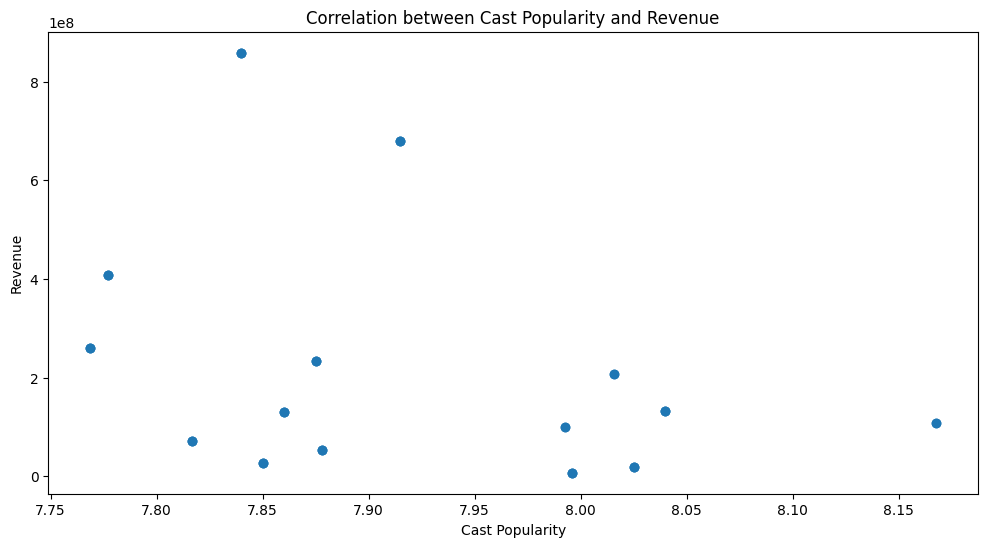

In [25]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.scatter(df['Cast_Popularity'],df['Gross'])
plt.xlabel('Cast Popularity')
plt.ylabel('Revenue')
plt.title('Correlation between Cast Popularity and Revenue')

# **Predictive Analysis**

Predict IMDb rating using:

->Genre

->Director

->Runtime

->Votes

->Gross revenue

In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
df = pd.read_csv('imdb_top_1000.csv')
df['Gross'] = df['Gross'].str.replace(',','')
df['Gross'] = pd.to_numeric(df['Gross'],errors='coerce')
df = df.dropna(subset='Gross')
df

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,28341469.0
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,134966411.0
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,534858444.0
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,57300000.0
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,4360000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
990,https://m.media-amazon.com/images/M/MV5BYjRmY2...,Giù la testa,1971,PG,157 min,"Drama, War, Western",7.6,A low-life bandit and an I.R.A. explosives exp...,77.0,Sergio Leone,Rod Steiger,James Coburn,Romolo Valli,Maria Monti,30144,696690.0
991,https://m.media-amazon.com/images/M/MV5BMzAyND...,Kelly's Heroes,1970,GP,144 min,"Adventure, Comedy, War",7.6,A group of U.S. soldiers sneaks across enemy l...,50.0,Brian G. Hutton,Clint Eastwood,Telly Savalas,Don Rickles,Carroll O'Connor,45338,1378435.0
992,https://m.media-amazon.com/images/M/MV5BMjAwMT...,The Jungle Book,1967,U,78 min,"Animation, Adventure, Family",7.6,Bagheera the Panther and Baloo the Bear have a...,65.0,Wolfgang Reitherman,Phil Harris,Sebastian Cabot,Louis Prima,Bruce Reitherman,166409,141843612.0
994,https://m.media-amazon.com/images/M/MV5BZjQyMG...,A Hard Day's Night,1964,U,87 min,"Comedy, Music, Musical",7.6,"Over two ""typical"" days in the life of The Bea...",96.0,Richard Lester,John Lennon,Paul McCartney,George Harrison,Ringo Starr,40351,13780024.0


In [27]:
df['Runtime'] = df['Runtime'].str.replace('min','')
df['Runtime'] = pd.to_numeric(df['Runtime'],errors='coerce')
df=  df.dropna(subset='Runtime')
df

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,28341469.0
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,134966411.0
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,534858444.0
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,57300000.0
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,4360000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
990,https://m.media-amazon.com/images/M/MV5BYjRmY2...,Giù la testa,1971,PG,157,"Drama, War, Western",7.6,A low-life bandit and an I.R.A. explosives exp...,77.0,Sergio Leone,Rod Steiger,James Coburn,Romolo Valli,Maria Monti,30144,696690.0
991,https://m.media-amazon.com/images/M/MV5BMzAyND...,Kelly's Heroes,1970,GP,144,"Adventure, Comedy, War",7.6,A group of U.S. soldiers sneaks across enemy l...,50.0,Brian G. Hutton,Clint Eastwood,Telly Savalas,Don Rickles,Carroll O'Connor,45338,1378435.0
992,https://m.media-amazon.com/images/M/MV5BMjAwMT...,The Jungle Book,1967,U,78,"Animation, Adventure, Family",7.6,Bagheera the Panther and Baloo the Bear have a...,65.0,Wolfgang Reitherman,Phil Harris,Sebastian Cabot,Louis Prima,Bruce Reitherman,166409,141843612.0
994,https://m.media-amazon.com/images/M/MV5BZjQyMG...,A Hard Day's Night,1964,U,87,"Comedy, Music, Musical",7.6,"Over two ""typical"" days in the life of The Bea...",96.0,Richard Lester,John Lennon,Paul McCartney,George Harrison,Ringo Starr,40351,13780024.0


In [28]:
df = df.dropna(subset=['Genre','Director','Runtime','No_of_Votes','Meta_score','Gross'])

In [29]:
from sklearn.preprocessing import LabelEncoder
genre_encoder = LabelEncoder()
df['Genre_encoded'] = genre_encoder.fit_transform(df['Genre'])

/tmp/ipykernel_20051/1142346706.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Genre_encoded'] = genre_encoder.fit_transform(df['Genre'])


In [30]:
director_encoder = LabelEncoder()
df['Director_encoded'] = director_encoder.fit_transform(df['Director'])

/tmp/ipykernel_20051/3567677891.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Director_encoded'] = director_encoder.fit_transform(df['Director'])


In [31]:
X = df[['Genre_encoded','Director_encoded','Runtime','Meta_score','No_of_Votes','Gross']]
y = df['IMDB_Rating']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
model = LinearRegression()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
y_pred[:5]


array([7.64534784, 7.7966522 , 7.83117135, 7.85434216, 7.8531092 ])

In [32]:
mse = mean_squared_error(y_test,y_pred)
print('Mean_Absolute_Error:',mse)

Mean_Absolute_Error: 0.04063506558218117


Insights

Model predictions are off by around 0.055 IMDb rating points on average.

In [33]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test,y_pred)
print('r2_score:',r2)

r2_score: 0.508974771429068


Insights

Model explains 50% of the variation in IMDb ratings.

Predicted Rating vs Actual Rating

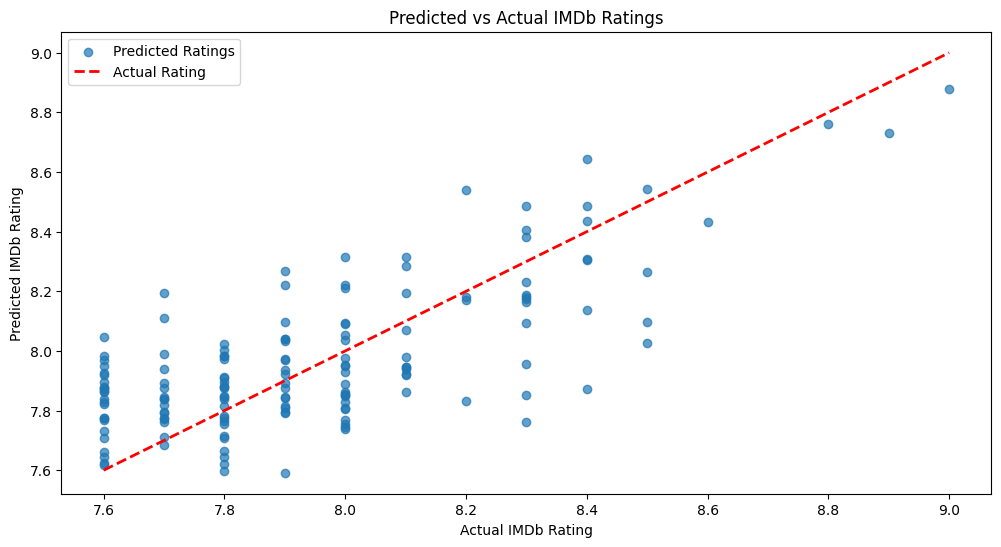

In [34]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12,6))

plt.scatter(y_test, y_pred, alpha=0.7, label='Predicted Ratings')


line = np.linspace(y_test.min(), y_test.max(), 100)

plt.plot(
    line,
    line,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Actual Rating '
)

plt.xlabel('Actual IMDb Rating')
plt.ylabel('Predicted IMDb Rating')

plt.title('Predicted vs Actual IMDb Ratings')

plt.legend()

plt.show()

Overall insights

Built a regression model to predict IMDb ratings with 50% accuracy using machine learning.

# **Predict Movie Revenue**

Predictions of how much a movie will earn

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Star1_encoded'] = le.fit_transform(df['Star1'])
df['Star2_encoded'] = le.fit_transform(df['Star2'])
df['Star3_encoded'] = le.fit_transform(df['Star3'])
df['Star4_encoded'] = le.fit_transform(df['Star4'])

X = df[['Genre_encoded', 'No_of_Votes', 'Star1_encoded', 'Star2_encoded',
        'Star3_encoded', 'Star4_encoded', 'Director_encoded', 'IMDB_Rating']]
y = df['Gross']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred[:5]

/tmp/ipykernel_20051/3158142153.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Star1_encoded'] = le.fit_transform(df['Star1'])
/tmp/ipykernel_20051/3158142153.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Star2_encoded'] = le.fit_transform(df['Star2'])
/tmp/ipykernel_20051/3158142153.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.

array([ 26258801.57129562,  10430640.51283622,  -1249554.06356061,
       -11176323.49652123, -14112206.39833152])

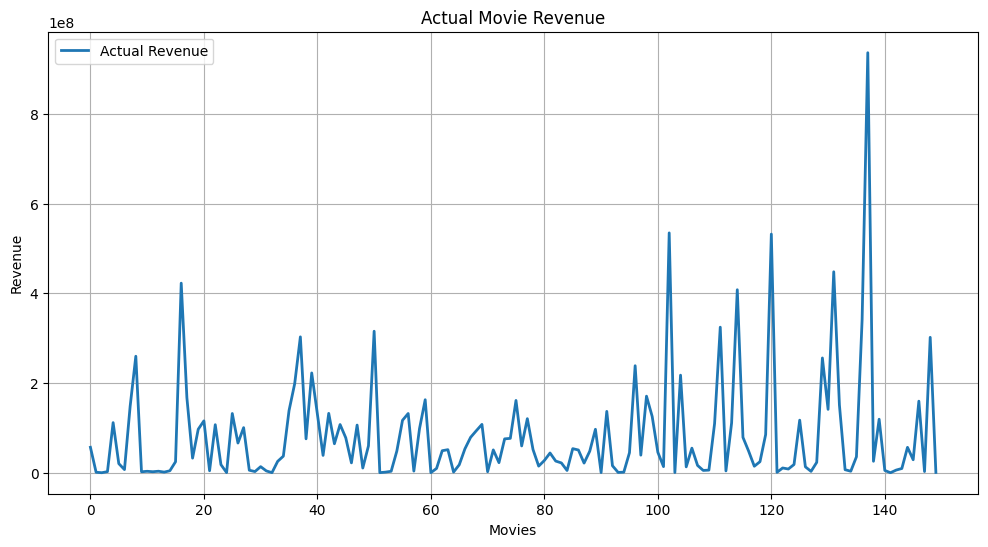

In [36]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    linestyle='-',
    linewidth=2,
    label='Actual Revenue'
)

plt.xlabel("Movies")
plt.ylabel("Revenue")

plt.title("Actual Movie Revenue")

plt.grid(True)

plt.legend()

plt.show()


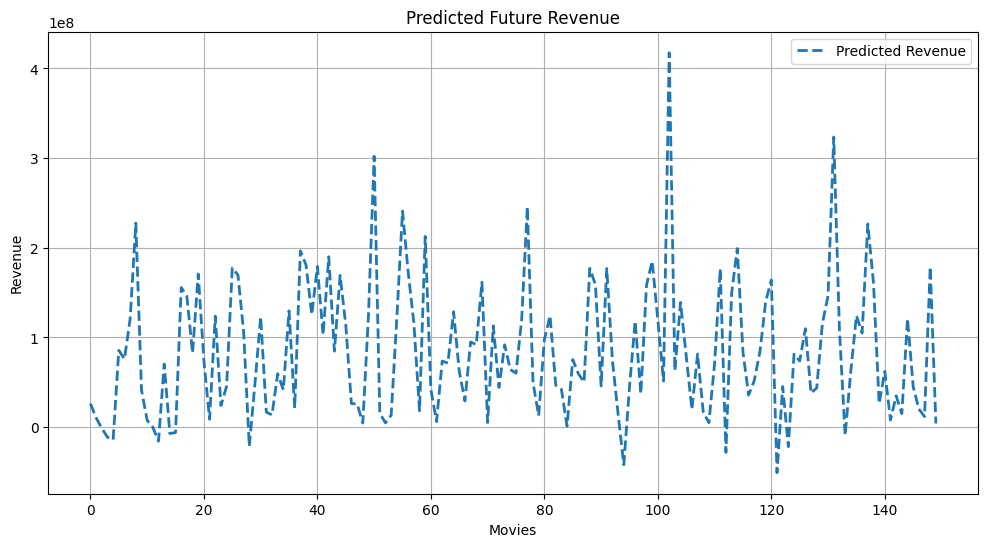

In [37]:
plt.figure(figsize=(12,6))

plt.plot(
    y_pred,
    linestyle='--',
    linewidth=2,
    label='Predicted Revenue'
)

plt.xlabel("Movies")
plt.ylabel("Revenue")

plt.title("Predicted Future Revenue")

plt.grid(True)

plt.legend()

plt.show()

Insights

Hit or Flop Classification

The predicted revenue graph demonstrates a sharp decline after top-performing movies, suggesting that the movie industry follows a long-tail revenue distribution where only a limited number of films achieve blockbuster-level earnings while the majority generate moderate revenue.

# `**Prescriptive Analysis**`

Duration optimization

Ideal movie length for higher rating/revenue

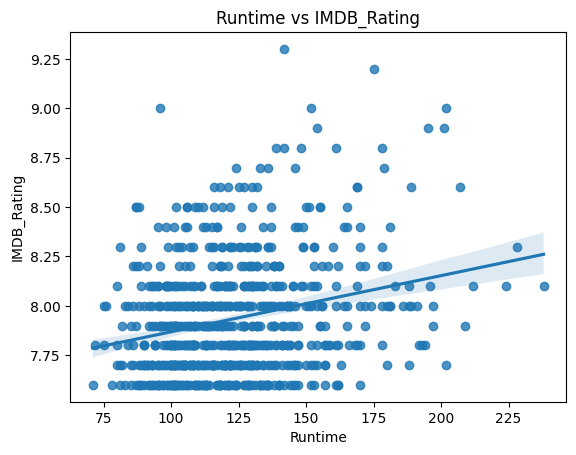

In [39]:
import seaborn as sns
sns.regplot(x=df['Runtime'],y=df['IMDB_Rating'])
plt.xlabel('Runtime')
plt.ylabel('IMDB_Rating')
plt.title('Runtime vs IMDB_Rating')
plt.show()

In [40]:
bins = [0,90,120,150,180,300]

labels = [
    'Short (<90 min)',
    'Medium (90-120 min)',
    'Long (120-150 min)',
    'Very Long (150-180 min)',
    'Extremely Long (>180 min)'
]

df['Runtime_Category'] = pd.cut(df['Runtime'],bins=bins,labels=labels)

/tmp/ipykernel_20051/2872518374.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Runtime_Category'] = pd.cut(df['Runtime'],bins=bins,labels=labels)


In [41]:
revenue_analysis = df.groupby('Runtime_Category')['Gross'].mean()

/tmp/ipykernel_20051/893144100.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_analysis = df.groupby('Runtime_Category')['Gross'].mean()


In [42]:
print(revenue_analysis)

Runtime_Category
Short (<90 min)              5.064510e+07
Medium (90-120 min)          5.872344e+07
Long (120-150 min)           8.805123e+07
Very Long (150-180 min)      1.012976e+08
Extremely Long (>180 min)    1.184722e+08
Name: Gross, dtype: float64


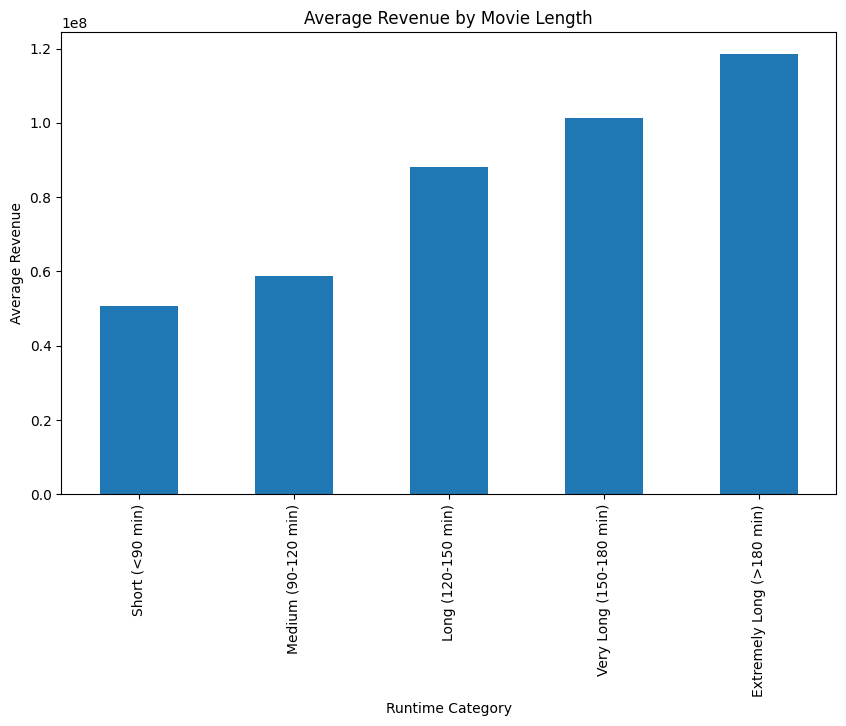

In [43]:
import matplotlib.pyplot as plt
revenue_analysis.plot(kind='bar',figsize=(10,6))
plt.xlabel('Runtime Category')
plt.ylabel('Average Revenue')
plt.title('Average Revenue by Movie Length')
plt.show()

Insights

Movies with runtime longer than 180 minutes generated the highest average box office revenue in the dataset, indicating that large-scale epic and franchise films tend to perform strongly commercially.

Why do long  movies earn more revenue?

In [45]:
epic_movies = df[df['Runtime'] > 180]
epic_movies[['Series_Title','Genre','IMDB_Rating','No_of_Votes','Gross']].head(10)

,Series_Title,Genre,IMDB_Rating,No_of_Votes,Gross
3,The Godfather: Part II,"Crime, Drama",9.0,1129952,57300000.0
5,The Lord of the Rings: The Return of the King,"Action, Adventure, Drama",8.9,1642758,377845905.0
7,Schindler's List,"Biography, Drama, History",8.9,1213505,96898818.0
25,The Green Mile,"Crime, Drama, Fantasy",8.6,1147794,136801374.0
31,Shichinin no samurai,"Action, Adventure, Drama",8.6,315744,269061.0
59,Avengers: Endgame,"Action, Adventure, Drama",8.4,809955,858373000.0
116,Lawrence of Arabia,"Adventure, Biography, Drama",8.3,268085,44824144.0
206,Kis Uykusu,Drama,8.1,46547,165520.0
247,Lagaan: Once Upon a Time in India,"Adventure, Drama, Musical",8.1,105036,70147.0
274,Fanny och Alexander,Drama,8.1,57784,4971340.0


In [47]:
epic_movies = df[df['Runtime'] > 180]['Gross'].mean()
epic_movies

np.float64(118472247.74074075)

In [48]:
medium_movies = df[(df['Runtime'] >=90) & (df['Runtime'] <= 120 )]['Gross'].mean()
medium_movies

np.float64(59196048.69275362)

In [51]:
epic_votes = df[df['Runtime'] > 180]['No_of_Votes'].mean()
epic_votes

np.float64(383304.5925925926)

Insights

Movies longer than 180 minutes generated an average revenue of 118 million dollars, compared to 59 million dollars for medium-length movies(90-120 mins)